### データサイエンス実践A 2025 (11/11講義資料)

In [1]:
# 数値演算、描画用ライブラリ読み込み
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# グラフをinline表示可能にする
%matplotlib inline

# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

# 日本語表示用ライブラリ（matplotlibで日本語を使用したい場合）
try:
  import japanize_matplotlib
except ModuleNotFoundError:
  # 初回だけインストールするので時間がかかる
  !pip install japanize-matplotlib
  import japanize_matplotlib

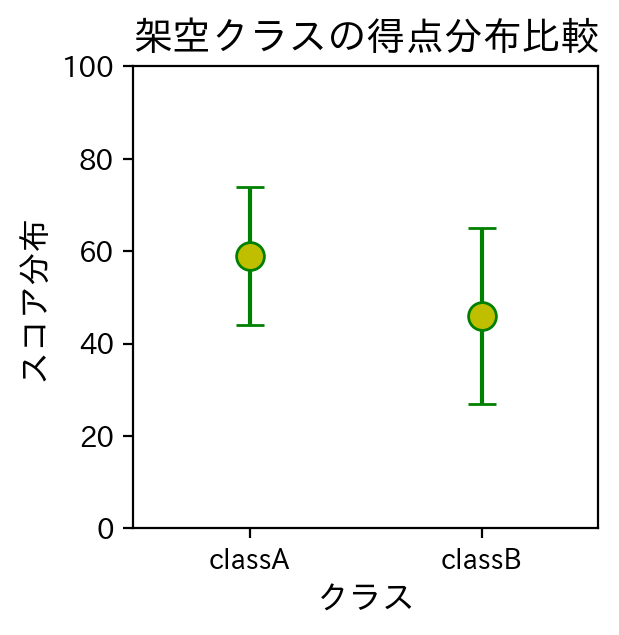

In [2]:
# データ作成（ダミー）
classes = ['classA', 'classB']
mean_score = [59, 46]
errorbar = [15, 19]

# 散布図の作成
plt.figure(figsize=(3,3))
#plt.scatter(classes, mean_score)

# エラーバー付き散布図の作成
plt.errorbar(classes, mean_score, yerr=errorbar, capsize=5, fmt='o', markersize=10, ecolor='g', markeredgecolor="g", color='y')

# グラフ軸範囲指定
plt.xlim(-0.5, 1.5)
plt.ylim(0, 100)

# グラフタイトル及び各軸の名称
plt.title('架空クラスの得点分布比較', fontsize=14)
plt.xlabel('クラス', fontsize=12)
plt.ylabel('スコア分布', fontsize=12)

# グラフ描画
plt.show()

### グラフの復習
plt.plot(), plt.scatter(), plt.bar(), plt.hist(), plt.boxplot(), ...

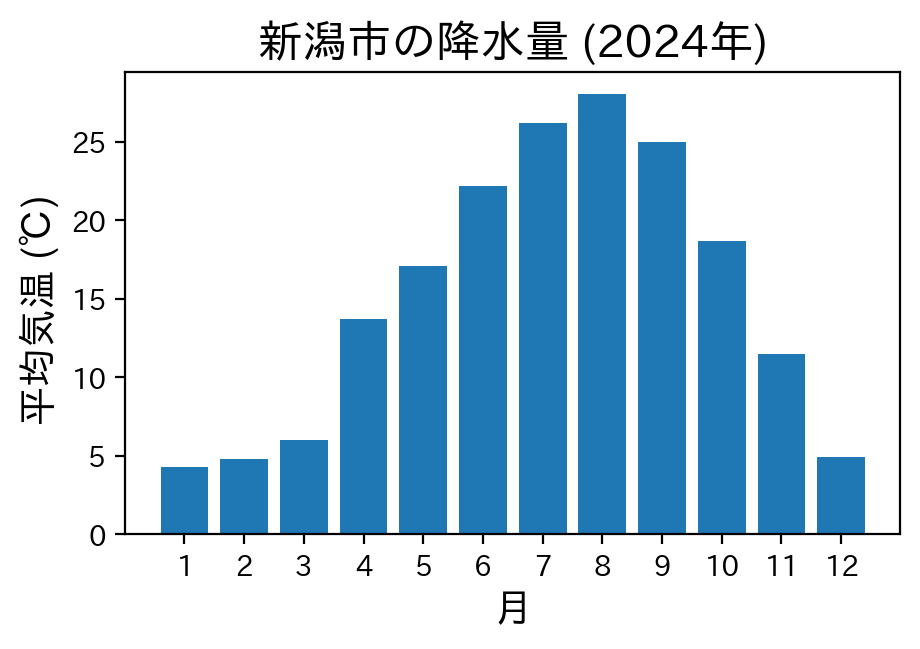

In [3]:
# データ準備（list形式)
month = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
temp = [4.3, 4.8, 6.0, 13.7, 17.1, 22.2, 26.2, 28.0, 25.0, 18.7, 11.5, 4.9]
rain = [180.0, 114.5, 168.0, 54.0, 128.0, 57.0, 376.5, 42.0, 292.0, 144.5, 246.5, 262.5]

# 棒グラフの作成
plt.figure(figsize=(5,3))

# グラフの種類を並べてみる

# 1引数でOKなグラフ（折れ線グラフ）
# plt.plot(temp)

# 2引数必要なグラフ（散布図・棒グラフ）
plt.bar(month, temp)
# plt.scatter(month, temp)

# 一群のデータが必要なグラフ（ヒストグラム・箱ひげ図）
data = [57,76,75,62,66,57,70,67,78,67,55,72,79,61,56,76,72,69,71,76,69,71,73,
        67,67,71,58,65,74,69,77,74,75,77,65,73,84,66,63,53,56,71,63,63,68,70,
        77,69,73,62,64,57,79,79,64,57,66,83,64,61,68,57,48,69,67,57,58,71,73,
        74,68,56,71,58,63,80,67,60,68,67,55,59,51,63,71,75,71,61,95,67,71,68,
        72,61,67,73,60,65,81,64]

# plt.hist(data)
#plt.boxplot(data)

# 必要な情報追加
plt.title('新潟市の降水量 (2024年)', fontsize=16)
plt.xlabel('月', fontsize=14)
plt.ylabel("平均気温 (℃) ", fontsize=14)
plt.xticks(range(1,13))

# グラフ描画
plt.show()

### エラーバーについて：初めて人類が円周率を求める世界線を考える
例えば、直径１ｍの円周の長さを紐で何度も繰り返し測ってヒストグラムを作成し、円周率の真値を追い込む

In [4]:
# 固定した乱数の生成
rng = np.random.default_rng(348309421) # seedの設定（空も可）
pi_data = rng.normal(np.pi, 0.10, 1000)  # 平均 3.1415...，標準偏差 0.10 の正規分布の乱数 1000個の配列
pi_data

array([3.0992514 , 3.1346229 , 3.2887813 , 3.25390168, 3.08793387,
       3.1442765 , 3.22840436, 3.12365686, 3.17888468, 3.16336681,
       3.08744796, 3.11931256, 3.33043018, 3.06615599, 3.10060991,
       3.07524618, 3.10695728, 3.19227747, 3.03688857, 3.0744    ,
       3.1978328 , 3.13521122, 3.09740497, 3.15047294, 3.0291959 ,
       3.02042558, 3.12019494, 3.44408762, 2.92889405, 3.34994754,
       3.17392977, 3.26041117, 3.22291692, 3.02129861, 2.99044523,
       3.15438863, 3.29077726, 3.17347927, 3.15846144, 3.00389773,
       3.09003188, 3.10305408, 3.14150156, 3.23785833, 3.1638368 ,
       3.14587361, 3.32439036, 3.1740928 , 3.24027108, 3.03992656,
       2.96726296, 3.23834994, 3.2230961 , 2.88788054, 3.29172459,
       3.16058929, 3.15569881, 3.07968576, 3.09339822, 3.21960103,
       3.02514437, 3.23002547, 3.17234385, 2.95809435, 3.20845319,
       3.25345098, 3.14758303, 3.13712533, 3.11825564, 3.14702626,
       3.10135798, 3.3886006 , 2.84253149, 3.20458176, 3.08581

平均:  3.141592653589793   分散:  0.1


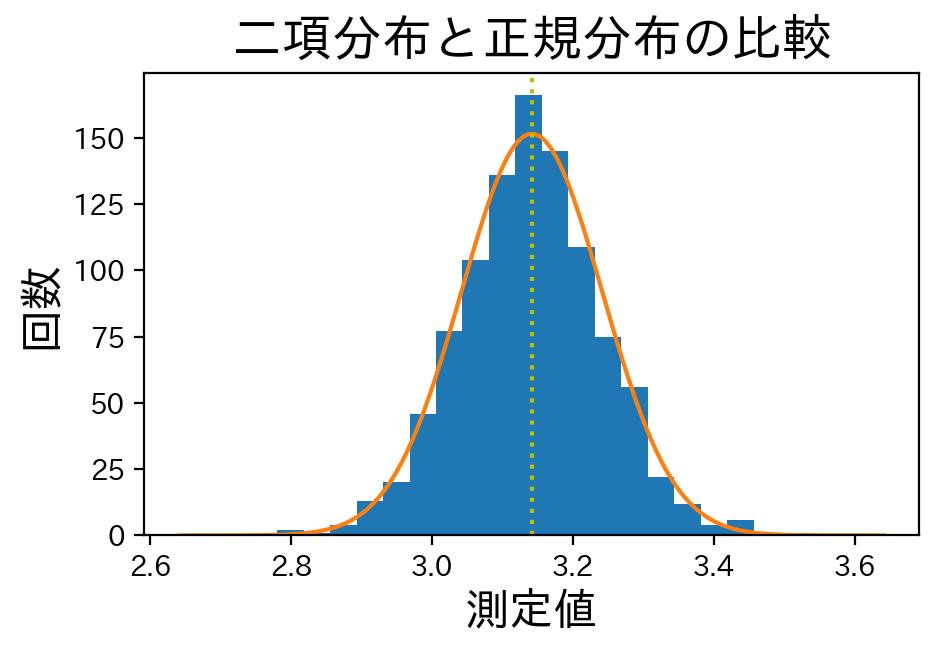

In [5]:
# 二項分布・正規分布を扱うライブラリをインポート
from scipy.stats import norm, binom

mu = np.pi
std = 0.1

# 固定した乱数の生成
rng = np.random.default_rng(348309421) # seedの設定（空も可）
pi_data = rng.normal(np.pi, std, 1000)  # 正規分布の乱数1000個の配列

plt.figure(figsize=(5,3))
# ヒストグラム作成
plt.hist(pi_data, bins=20)

# 折れ線グラフの描画
x_norm = np.linspace(np.pi-1/2,np.pi+1/2,128)
plt.plot(x_norm, norm.pdf(x_norm, loc=mu, scale=std)*38)  # 正規分布

# （知らないはずの）真値に補助線を引く
plt.axvline(x=np.pi, c='y', ls=':')

plt.title('二項分布と正規分布の比較', fontsize=18)
plt.xlabel('測定値', fontsize=16)
plt.ylabel('回数', fontsize=16)
print("平均: ", mu, "  分散: ", std)

# グラフ描画
plt.show()

平均:  3.141592653589793   分散:  0.1
平均:  3.141592653589793   分散:  0.02


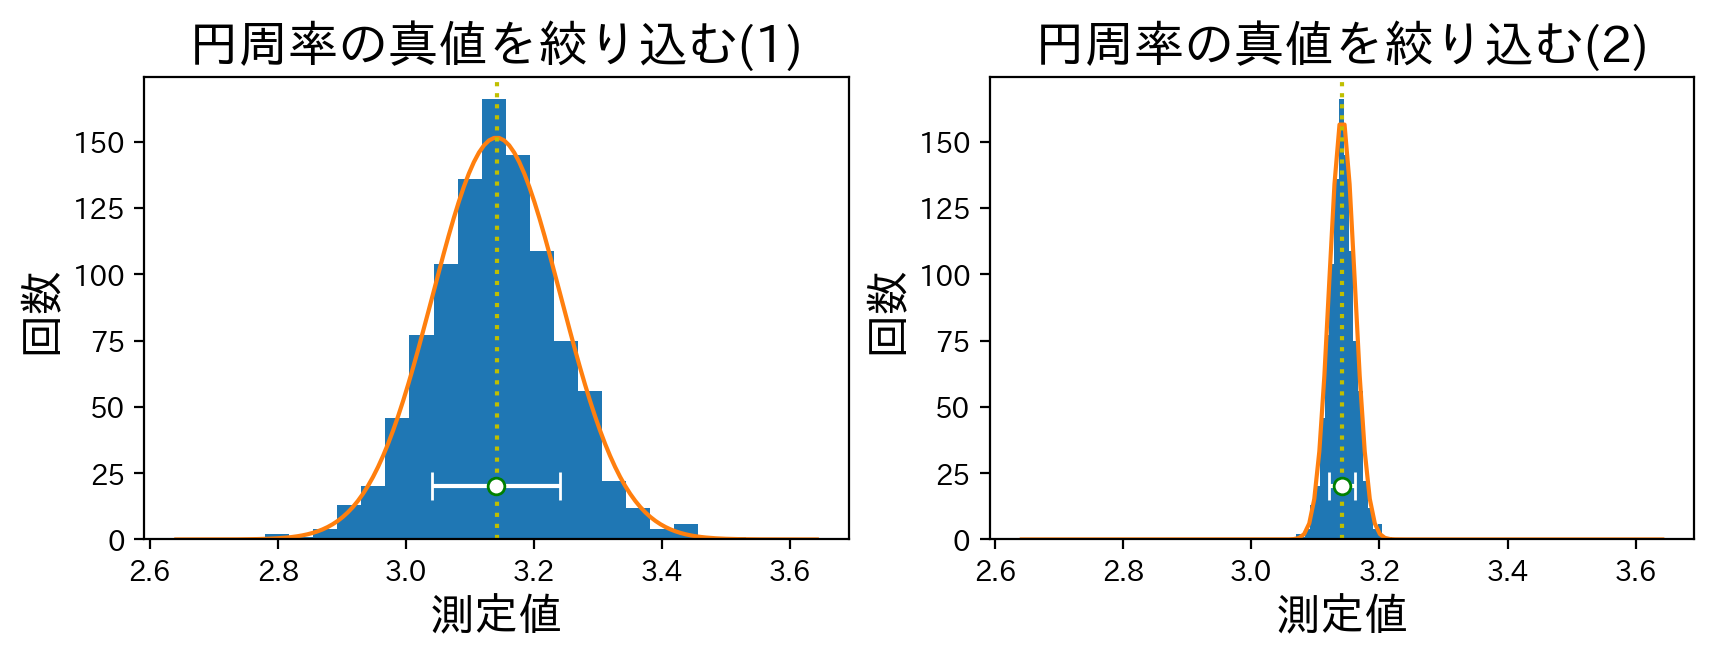

In [6]:
# 二項分布・正規分布を扱うライブラリをインポート
from scipy.stats import norm, binom

# 複数グラフ全体の描画範囲を指定
plt.figure(figsize=(10,3))

# 1x2 （縦1、横2）のグラフの 1番目のグラフ作成
plt.subplot(1, 2, 1)

mu = np.pi
std = 0.1

# 固定した乱数の生成
rng = np.random.default_rng(348309421) # seedの設定（空も可）
data = rng.normal(np.pi, std, 1000)  # 正規分布の乱数1000個の配列

# ヒストグラム作成
plt.hist(data, bins=20)

# 折れ線グラフの描画
x_norm = np.linspace(np.pi-1/2,np.pi+1/2,128)
plt.plot(x_norm, norm.pdf(x_norm, loc=mu, scale=std)*38)  # 正規分布
plt.axvline(x=np.pi, c='y', ls=':')

# エラーバー設定
plt.errorbar(data.mean(), 20, xerr=data.std(), capsize=5, fmt='wo', markersize=6, ecolor='w', markeredgecolor="g")

# タイトル・軸ラベルの指定
plt.title('円周率の真値を絞り込む(1)', fontsize=18)
plt.xlabel('測定値', fontsize=16)
plt.ylabel('回数', fontsize=16)
print("平均: ", mu, "  分散: ", std)

# 1x2 （縦1、横2）のグラフの 2番目のグラフ作成
plt.subplot(1, 2, 2)

mu = np.pi
std = 0.02

# 固定した乱数の生成
rng = np.random.default_rng(348309421) # seedの設定（空も可）
data = rng.normal(np.pi, std, 1000)  # 正規分布の乱数20個の配列

# ヒストグラム作成
plt.hist(data, bins=20)

# 折れ線グラフの描画
x_norm = np.linspace(np.pi-1/2,np.pi+1/2,128)
plt.plot(x_norm, norm.pdf(x_norm, loc=mu, scale=std)*8)  # 正規分布
plt.axvline(x=np.pi, c='y', ls=':')

# エラーバー設定
plt.errorbar(data.mean(), 20, xerr=data.std(), capsize=5, fmt='wo', markersize=6, ecolor='w', markeredgecolor="g")

# タイトル・軸ラベルの指定
plt.title('円周率の真値を絞り込む(2)', fontsize=18)
plt.xlabel('測定値', fontsize=16)
plt.ylabel('回数', fontsize=16)
print("平均: ", mu, "  分散: ", std)

# グラフ描画
plt.show()

区間 [-1.0*sigma, 1.0*sigma]に入る確率: 0.683


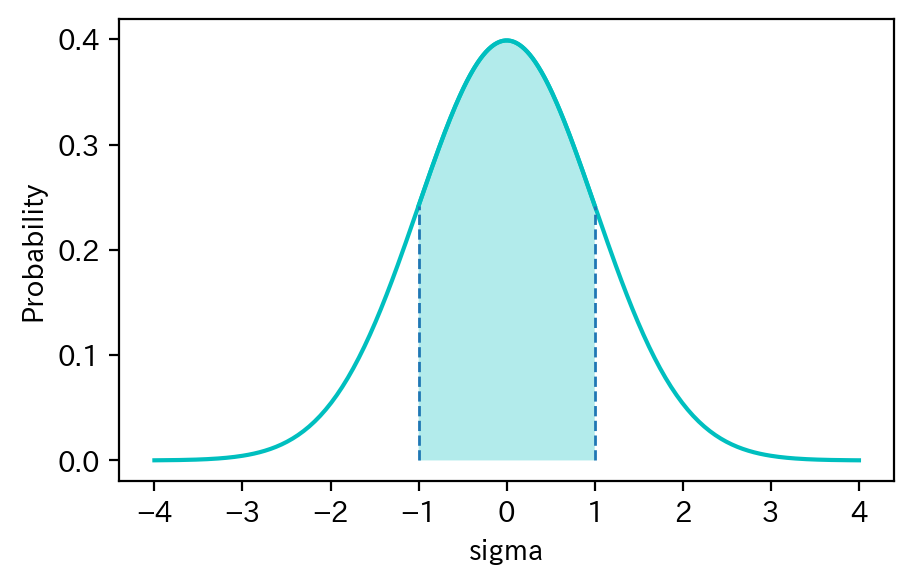

In [7]:
# 正規分布を扱うライブラリをインポート
from scipy.stats import norm

# 正規分布のパラメータ設定
center = 0
sigma = 1
z_pos = 1

# 正規分布データ作成
x1 = np.linspace(center - 4*sigma, center + 4*sigma, 2**8)
y1 = norm.pdf(x1, loc=center, scale=sigma)
x2 = np.linspace(center - z_pos*sigma, center + z_pos*sigma, 2**8)
y2 = norm.pdf(x2, loc=center, scale=sigma)

# 折れ線グラフ作成
plt.figure(figsize=(5,3))
plt.plot(x1, y1, color="c")
plt.plot(x2, y2, color="c")
plt.fill_between(x2, 0, y2, facecolor='c', alpha=0.3)

# 垂直補助線（ある点までの補助線）
plt.vlines(x=-z_pos, ymin=-0, ymax=norm.pdf(z_pos,loc=center,scale=sigma),
           linestyles='dashed', linewidths=1)
plt.vlines(x=z_pos, ymin=-0, ymax=norm.pdf(z_pos,loc=center,scale=sigma),
           linestyles='dashed', linewidths=1)

# ラベル情報の追加
plt.xlabel("sigma")
plt.ylabel("Probability")

# 色塗り範囲の確率計算
prob = 2*norm.cdf(x=z_pos, loc=center, scale=sigma)-1
print(f"区間 [{-z_pos: .1f}*sigma,{z_pos: .1f}*sigma]に入る確率:{prob: .3f}")

# グラフ描画
plt.show()

### 実際の使用例
[Matplotlib 軸周り完璧マスターガイド | 軸・軸目盛・目盛り線の設定](https://www.yutaka-note.com/entry/matplotlib_axis)

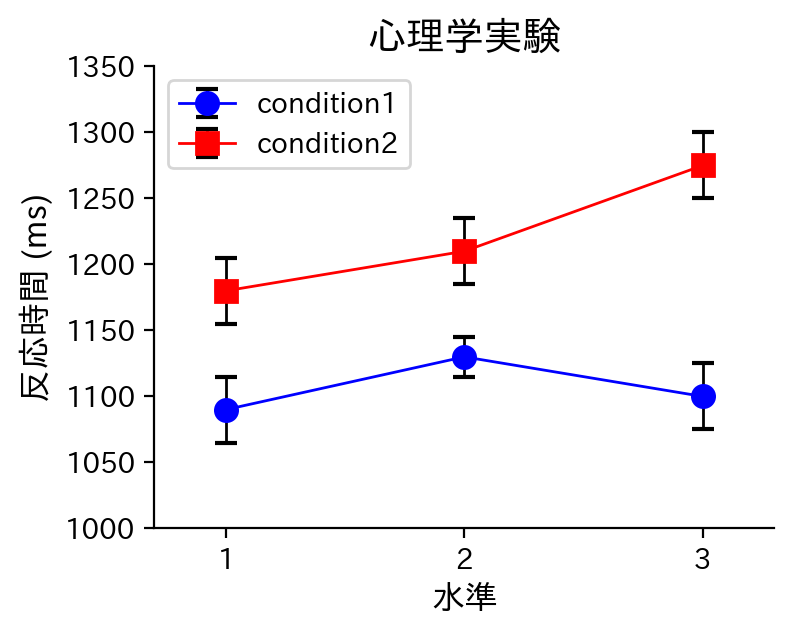

In [8]:
# データ
x_value = [1, 2, 3]
y1_value = [1090, 1130, 1100]
y2_value = [1180, 1210, 1275]

y1_error = [25, 15, 25]
y2_error = [25, 25, 25]

# グラフサイズ指定
fig=plt.figure(figsize=(4,3))

# エラーバー付グラフ作成
plt.errorbar(x_value, y1_value, yerr=y1_error, fmt='bo-',  # 全体（データ、マーカー種・線種指定）
             markersize=8, linewidth=1, ecolor="k", capsize=4, capthick=1.5, label='condition1')   # 線およびエラーバー関連

plt.errorbar(x_value, y2_value, yerr=y2_error, fmt='rs-',  # 全体（データ、マーカー種・線種指定）
             markersize=8, linewidth=1, ecolor="k", capsize=4, capthick=1.5, label='condition2')   # 線およびエラーバー関連

# タイトル・軸ラベル設定
plt.title('心理学実験', fontsize=14)
plt.xlabel('水準', fontsize=12)
plt.ylabel('反応時間 (ms)', fontsize=12)

# 軸範囲指定
plt.xlim(0.7, 3.3)
plt.ylim(1000, 1350)

# x軸の表示する目盛を設定
plt.xticks(ticks=x_value, labels=[1, 2, 3])

# 上と右の軸線を消去
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 目盛の数字サイズ指定
plt.tick_params(labelsize=10)

# 凡例表示
plt.legend()

# グラフ描画
plt.show()

### リスト と np.array と pd.series

In [9]:
# list
temp = [4.3, 4.8, 6.0, 13.7, 17.1, 22.2, 26.2, 28.0, 25.0, 18.7, 11.5, 4.9]
temp

[4.3, 4.8, 6.0, 13.7, 17.1, 22.2, 26.2, 28.0, 25.0, 18.7, 11.5, 4.9]

In [10]:
# temp*1.5 # 繰り返しになる

In [11]:
np.sqrt(temp) # to array

array([2.07364414, 2.19089023, 2.44948974, 3.7013511 , 4.13521463,
       4.7116876 , 5.11859356, 5.29150262, 5.        , 4.32434966,
       3.39116499, 2.21359436])

In [12]:
np.mean(temp)

np.float64(15.200000000000001)

In [13]:
np.std(temp)

np.float64(8.56047117083322)

In [14]:
temp_array = np.array(temp)
temp_array

array([ 4.3,  4.8,  6. , 13.7, 17.1, 22.2, 26.2, 28. , 25. , 18.7, 11.5,
        4.9])

In [15]:
temp_array * 1.5

array([ 6.45,  7.2 ,  9.  , 20.55, 25.65, 33.3 , 39.3 , 42.  , 37.5 ,
       28.05, 17.25,  7.35])

In [16]:
temp_array.mean()

np.float64(15.200000000000001)

In [17]:
temp_array.std()

np.float64(8.56047117083322)

In [18]:
# 両方OK
np.mean(temp_array)

np.float64(15.200000000000001)

In [19]:
# 両方OK
np.std(temp_array)

np.float64(8.56047117083322)

### fmt 指定について
マーカー色、マーカー種、線種を一括で指定可能  
[document](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot)

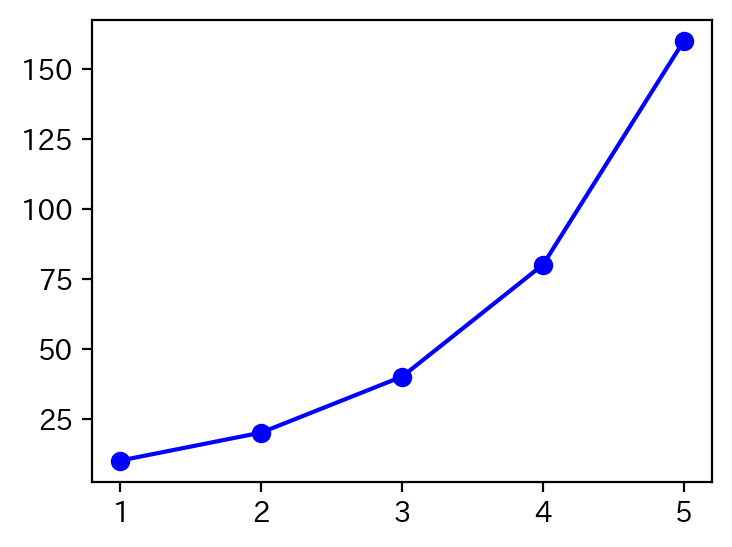

In [20]:
x = [1, 2, 3, 4, 5]
y = [10, 20, 40, 80, 160]

plt.figure(figsize=(4,3))
plt.plot(x, y, 'bo-')  # plt.plot(x, y, color='b', marker='o', linestyle='-') に同じ
plt.show()

### 折れ線、棒グラフへのエラーバー描画

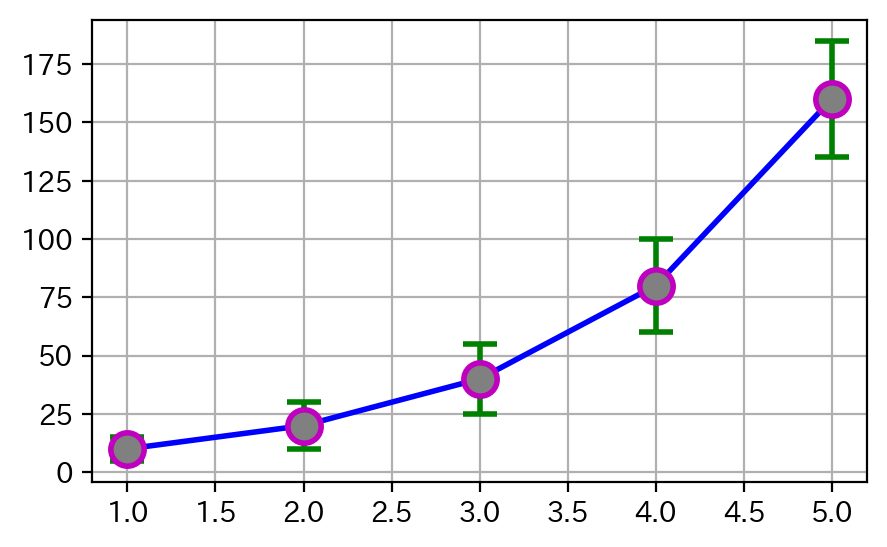

In [21]:
x_value = [1, 2, 3, 4, 5]
y_value = [10, 20, 40, 80, 160]

x_error = [0.1, 0.2, 0.3, 0.4, 0.5]
y_error = [5, 10, 15, 20, 25]

fig=plt.figure(figsize=(5,3))

plt.errorbar(x_value, y_value, yerr=y_error, fmt='o-',  # 全体（データ、マーカー種・線種指定）
             markersize=12, markerfacecolor='gray', markeredgecolor="m", markeredgewidth=2,   # マーカー関連
             color='b', linewidth=2, ecolor="g", capsize=6, capthick=2)                    # 線およびエラーバー関連
plt.tick_params(labelsize=10)
plt.grid()

plt.show()

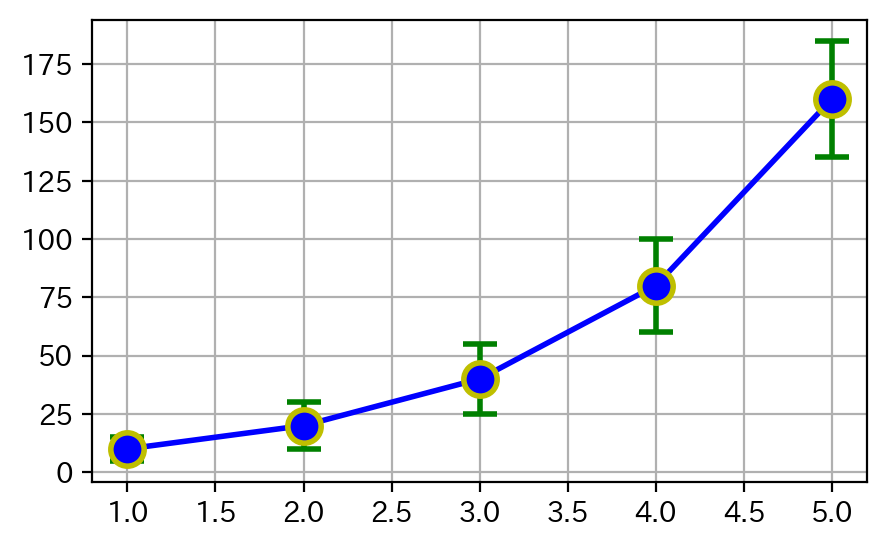

In [22]:
x_value = [1, 2, 3, 4, 5]
y_value = [10, 20, 40, 80, 160]

x_error = [0.1, 0.2, 0.3, 0.4, 0.5]
y_error = [5, 10, 15, 20, 25]

fig=plt.figure(figsize=(5,3))

plt.errorbar(x_value, y_value, yerr=y_error, marker='o', markersize=12,  markeredgecolor="y",
             markeredgewidth=2, color='b', linewidth=2, ecolor="g", capsize=6, capthick=2)
plt.tick_params(labelsize=10)
plt.grid()

plt.show()

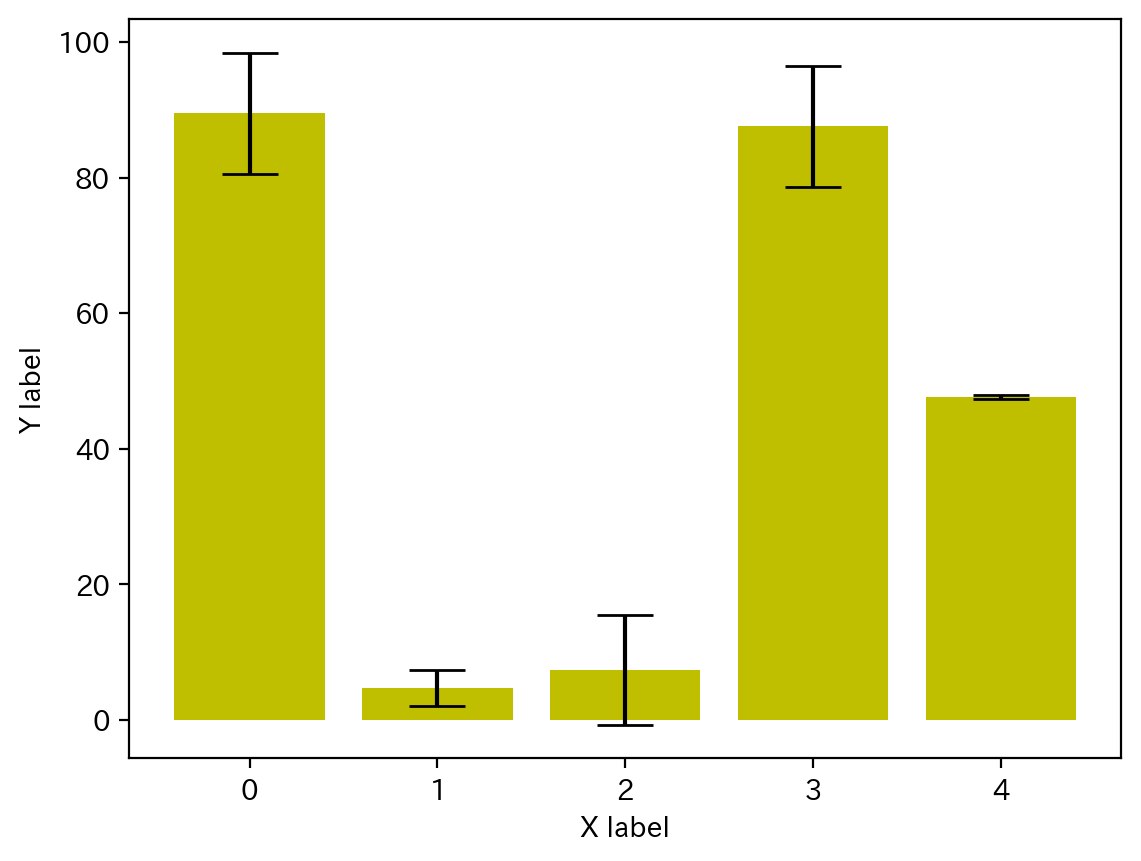

In [23]:
# plt.bar のオプションのみ使用
x = np.arange(5)
y = np.random.rand(5)*100
yerr = np.random.rand(5)*10

plt.bar(x, y, yerr=yerr, color = 'y', ecolor='k', capsize=10)

plt.xlabel('X label')
plt.ylabel('Y label')
plt.show()

https://www.geeksforgeeks.org/python/add-error-bars-to-a-matplotlib-bar-plot/  
https://www.useful-python.com/matplotlib-bar/#ecolor

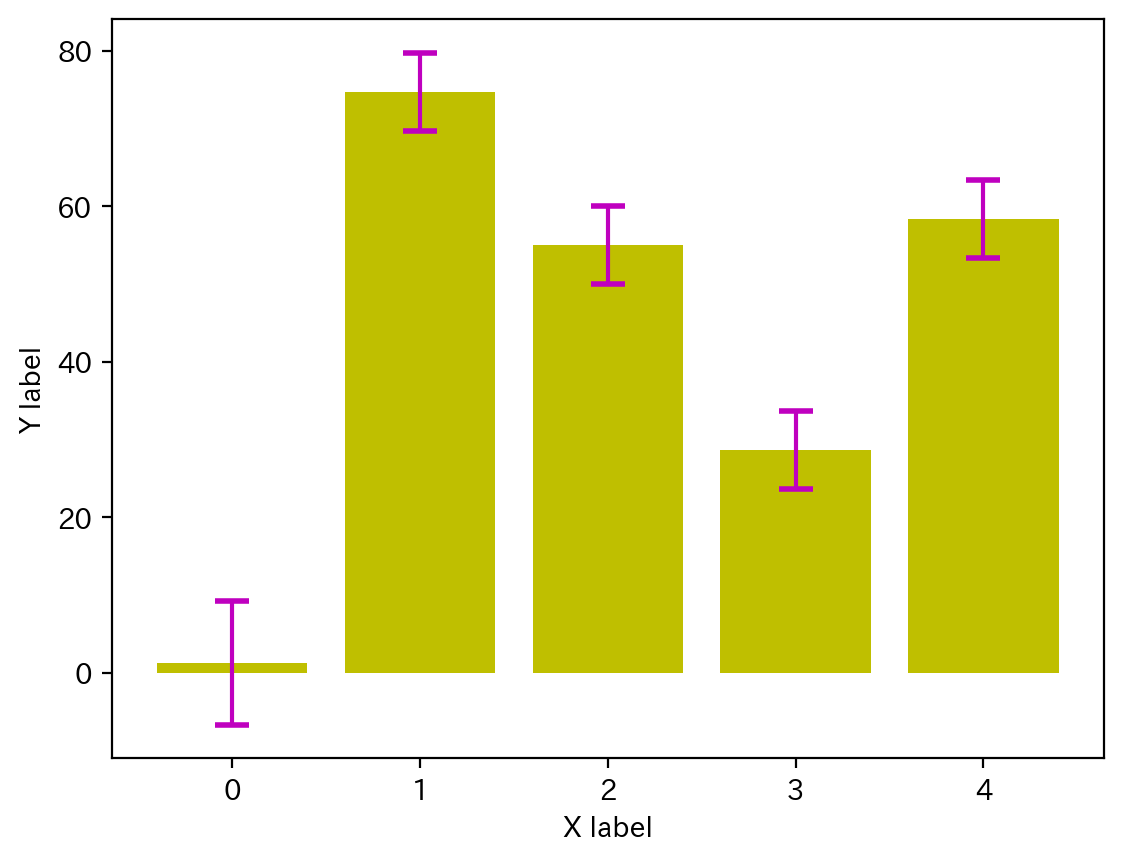

In [24]:
# plt.bar と plt.errorbar を両方使用するパターン

x = np.arange(5)
y = np.random.rand(5)*100
yerr = [8,5,5,5,5]

plt.bar(x, y, color = 'y')
plt.errorbar(x, y, yerr=yerr, marker='', linestyle='', ecolor='m', capsize=6, capthick=2)

plt.xlabel('X label')
plt.ylabel('Y label')
plt.show()

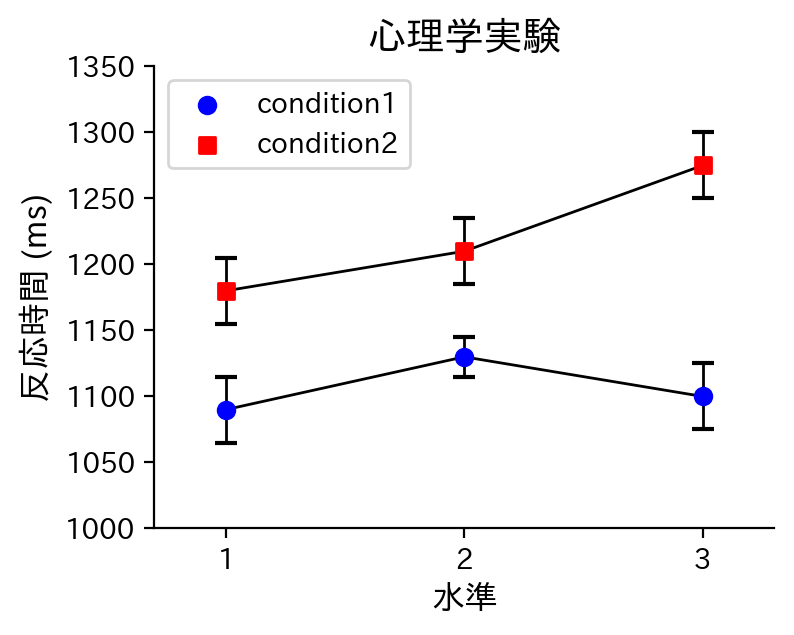

In [25]:
# plt.bar と plt.errorbar を両方使用するパターン

# データ
x_value = [1, 2, 3]
y1_value = [1090, 1130, 1100]
y2_value = [1180, 1210, 1275]

y1_error = [25, 15, 25]
y2_error = [25, 25, 25]

# グラフサイズ指定
fig=plt.figure(figsize=(4,3))

# 散布図作成
plt.scatter(x_value, y1_value, color='b', marker='o', label='condition1', zorder=2)
plt.scatter(x_value, y2_value, color='r', marker='s', label='condition2', zorder=2)

# エラーバー作成
plt.errorbar(x_value, y1_value, yerr=y1_error, fmt='k-',  # 全体（データ、マーカー種・線種指定）
             markersize=8, linewidth=1, ecolor="k", capsize=4, capthick=1.5, zorder=1)   # 線およびエラーバー関連

plt.errorbar(x_value, y2_value, yerr=y2_error, fmt='k-',  # 全体（データ、マーカー種・線種指定）
             markersize=8, linewidth=1, ecolor="k", capsize=4, capthick=1.5, zorder=1)   # 線およびエラーバー関連

# タイトル・軸ラベル設定
plt.title('心理学実験', fontsize=14)
plt.xlabel('水準', fontsize=12)
plt.ylabel('反応時間 (ms)', fontsize=12)

# 軸範囲指定
plt.xlim(0.7, 3.3)
plt.ylim(1000, 1350)

# x軸の表示する目盛を設定
plt.xticks(ticks=x_value, labels=[1, 2, 3])

# 上と右の軸線を消去
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 目盛の数字サイズ指定
plt.tick_params(labelsize=10)

# 凡例表示
plt.legend()

# グラフ描画
plt.show()